# 02 — M2: generator v0 — a graph-conditioned normalizing flow (no physics yet)

**Goal.** Get end-to-end *sampling* working: a model that, given a feeder graph, invents
whole days of operation — and grade it honestly against the M1 real data with the
validation methodology of Cramer et al. (IEEE Access 2022), plus baselines that make the
numbers meaningful. **No physics term yet** — this milestone measures what pure
statistics buys, so M3's physics ablation has a controlled starting point.

## Architecture (v0, decided in M0/M2)

- **One sample = one feeder-day**: N buses × 6 channels (Pd, Qd, Pg, Qg, Vm, Va) × 96
  steps, normalized per node to *nameplate* per-unit (all scales derivable from the
  static conditioning features — transfer-safe by construction).
- **Shared time-PCA basis** (96 → K=16 per channel, fitted on pooled node-days of the
  train feeders' train days): Cramer's PCA-flow trick, adapted so the basis is
  node- and feeder-agnostic. A feeder-day becomes an (N, 96)-coefficient array.
- **Graph-conditioned RealNVP**: affine coupling layers over *nodes* — the transformed
  node set alternates along BFS depth parity from the substation (the natural
  2-coloring of a radial feeder). The coupling conditioner is a 2-round
  message-passing GNN (series-admittance edge features, static nameplate + RWPE node
  features) **plus a mean-pooled global context** — one weather field drives every DER
  unit (M1 fig01), and a purely local conditioner could never coordinate feeder-wide
  export. Exact log-likelihood; weights shared across feeders.
- **Training**: maximum likelihood on 311 train days × 2 feeders (rural0, semiurb0),
  σ=0.01 dequantization noise (constant channels would otherwise have singular
  density), early stop on validation NLL, seed 42.

**Plan-B trigger (recorded before looking at results):** if the flow can't beat the
node-independent baseline on cross-node correlation *and* the Gaussian baseline on
tails/ramps, the documented fallback is a conditional VAE (M0).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
import sys
sys.path.insert(0, str(ROOT))
from gridfm.dataset import TimePCA, build_feeder, denormalize_days
from gridfm.flow import D_COND, GraphFlow, feeder_graph_tensors
from gridfm import metrics as M

C = dict(blue="#2a78d6", aqua="#1baf7a", yellow="#eda100", green="#008300",
         violet="#4a3aa7", red="#e34948")
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "figure.dpi": 110,
})
RES = ROOT / "results" / "m2"; RES.mkdir(parents=True, exist_ok=True)
SRC = {"real": C["blue"], "flow": C["aqua"], "independent": C["yellow"],
       "gaussian": C["violet"]}

TRAIN_FEEDERS = ["rural0", "semiurb0"]
feeders = {n: build_feeder(ROOT / "data" / "m1" / f"{n}_year.npz")
           for n in TRAIN_FEEDERS}
pca = TimePCA.load(ROOT / "checkpoints" / "timepca_k16.npz")
print("PCA cumulative explained variance per channel:",
      dict(zip(M.DYN_COLS, np.round(pca.explained.sum(axis=1), 4))))

PCA cumulative explained variance per channel: {'Pd': np.float32(0.9327), 'Qd': np.float32(0.8468), 'Pg': np.float32(0.9982), 'Qg': np.float32(0.9409), 'Vm': np.float32(0.9747), 'Va': np.float32(1.0)}


## The time basis — what K=16 keeps and what it throws away

The flow can only be as good as the basis it writes days in. Before grading the model,
grade the basis: how much of each channel's variance do 16 components carry, and what
does the reconstruction floor look like in physical units?

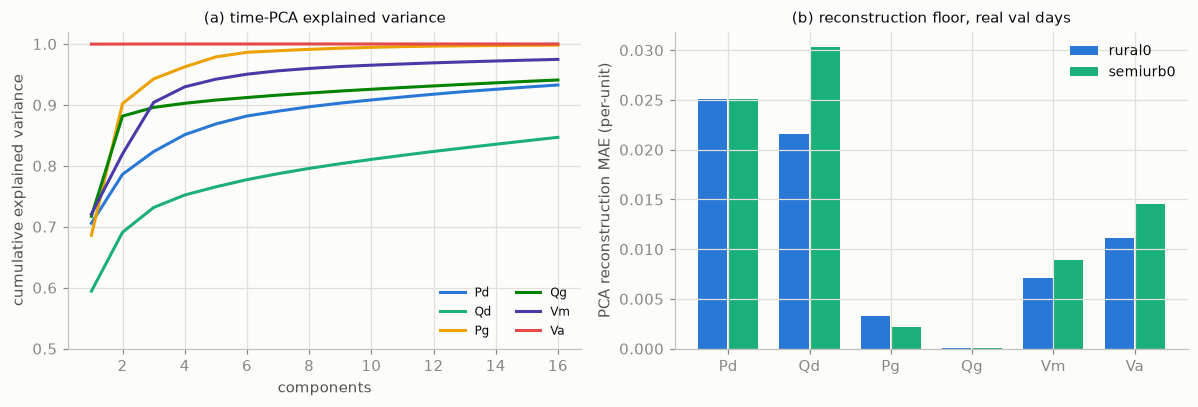

feeder,rural0,semiurb0
channel,,
Pd,0.0251,0.0251
Qd,0.0216,0.0303
Pg,0.0032,0.0022
Qg,0.0001,0.0001
Vm,0.0071,0.0090
Va,0.0111,0.0146


In [2]:
# fig05 — basis quality: cumulative EV + the reconstruction floor per channel
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
for c, name in enumerate(M.DYN_COLS):
    ax.plot(np.arange(1, pca.k + 1), np.cumsum(pca.explained[c]), lw=2,
            label=name, color=list(C.values())[c])
ax.set_xlabel("components"); ax.set_ylabel("cumulative explained variance")
ax.set_ylim(0.5, 1.02); ax.set_title("(a) time-PCA explained variance", fontsize=10)
ax.legend(frameon=False, fontsize=8, ncol=2)

# reconstruction floor: encode+decode real val days, physical-unit error
ax = axes[1]
rows = []
for n in TRAIN_FEEDERS:
    f = feeders[n]
    dv = f["days_pu"][f["val_idx"]]
    rec = pca.decode(pca.encode(dv))
    err_pu = np.abs(rec - dv)
    for c, name in enumerate(M.DYN_COLS):
        rows.append({"feeder": n, "channel": name,
                     "mae_pu": float(err_pu[:, :, c, :].mean())})
rec_df = pd.DataFrame(rows).pivot(index="channel", columns="feeder", values="mae_pu")
rec_df = rec_df.loc[M.DYN_COLS]
x = np.arange(len(rec_df))
for i, n in enumerate(TRAIN_FEEDERS):
    ax.bar(x + i * 0.38, rec_df[n], width=0.36, color=[C["blue"], C["aqua"]][i],
           label=n)
ax.set_xticks(x + 0.19); ax.set_xticklabels(rec_df.index)
ax.set_ylabel("PCA reconstruction MAE (per-unit)")
ax.set_title("(b) reconstruction floor, real val days", fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(RES / "fig05_basis.png", bbox_inches="tight")
plt.show()
rec_df.round(4)

**Reading fig05.** Pg is almost perfectly low-dimensional (99.8% in 16 components —
weather-driven smoothness), Vm/Va similarly compressible; Pd and especially Qd keep
~7–11% of their variance beyond the basis (individual household noise, which is genuinely
high-frequency). Everything the generator produces lives inside this basis, so the PCA
row in the final scorecard is the **fidelity ceiling** — no generator in this
representation can beat it. That ceiling is a deliberate v0 trade (Cramer's own design);
if M3 finds it binding, K is a knob.

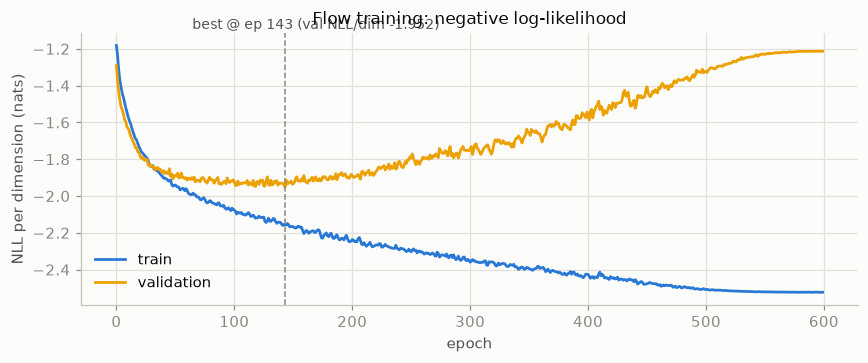

In [3]:
# training history — fig06
hist = pd.read_csv(RES / "history_v0.csv")
ck = torch.load(ROOT / "checkpoints" / "v0_best.pt", map_location="cpu",
                weights_only=False)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(hist.epoch, hist.train_nll_per_dim, lw=1.8, color=C["blue"], label="train")
ax.plot(hist.epoch, hist.val_nll_per_dim, lw=1.8, color=C["yellow"], label="validation")
ax.axvline(ck["epoch"], color=MUTED, lw=1, ls="--")
ax.annotate(f"best @ ep {ck['epoch']} (val NLL/dim {ck['val_nll']:.3f})",
            xy=(ck["epoch"], ck["val_nll"]), xytext=(ck["epoch"] * 0.45,
            hist.val_nll_per_dim.max() * 0.9), color=INK2, fontsize=9)
ax.set_xlabel("epoch"); ax.set_ylabel("NLL per dimension (nats)")
ax.set_title("Flow training: negative log-likelihood", fontsize=11)
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(RES / "fig06_training.png", bbox_inches="tight")
plt.show()

**Reading fig06.** Maximum-likelihood training is the stability argument for flows:
one smooth objective, no adversarial game. The train–validation gap is the overfitting
check — with only 622 training days, some gap is expected; the early-stopped checkpoint
is what everything below uses.

In [4]:
# generate: flow samples + the two baselines, all decoded to physical units
device = "cuda" if torch.cuda.is_available() else "cpu"
args = ck["args"]
model = GraphFlow(6 * args["k"], D_COND, n_layers=args["layers"],
                  hidden=args["hidden"]).to(device)
model.load_state_dict(ck["model"]); model.eval()

N_GEN = 400
rng = np.random.RandomState(42)
sets = {}      # sets[feeder][source] = physical days (D, N, C, 96)
for n in TRAIN_FEEDERS:
    f = feeders[n]
    g = feeder_graph_tensors(f, device)
    real_val = denormalize_days(f["days_pu"][f["val_idx"]], f["static"])
    real_train_pool = denormalize_days(f["days_pu"][f["train_idx"]], f["static"])

    zs = []
    for i in range(0, N_GEN, 100):
        zs.append(model.sample(min(100, N_GEN - i), g).cpu().numpy())
    flow_days = denormalize_days(pca.decode(np.concatenate(zs)), f["static"])

    indep = M.sample_independent(real_train_pool, N_GEN, rng)

    co_tr = pca.encode(f["days_pu"][f["train_idx"]])
    d_tr = co_tr.reshape(len(co_tr), -1)
    # Cramer-style PCA-Gaussian baseline: day-level PCA (64) + full-cov normal
    mu_d = d_tr.mean(0); Xc = d_tr - mu_d
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    kd = 64
    scores = Xc @ Vt[:kd].T
    mu_s, cov_s = scores.mean(0), np.cov(scores.T) + 1e-6 * np.eye(kd)
    zg = rng.multivariate_normal(mu_s, cov_s, N_GEN)
    co_g = (zg @ Vt[:kd] + mu_d).reshape(N_GEN, *co_tr.shape[1:]).astype(np.float32)
    gauss = denormalize_days(pca.decode(co_g), f["static"])

    pca_rec = denormalize_days(pca.decode(pca.encode(f["days_pu"][f["val_idx"]])),
                               f["static"])
    sets[n] = {"real": real_val, "flow": flow_days, "independent": indep,
               "gaussian": gauss, "pca_ceiling": pca_rec}
print({n: {k: v.shape for k, v in d.items()} for n, d in sets.items()})

{'rural0': {'real': (55, 95, 6, 96), 'flow': (400, 95, 6, 96), 'independent': (400, 95, 6, 96), 'gaussian': (400, 95, 6, 96), 'pca_ceiling': (55, 95, 6, 96)}, 'semiurb0': {'real': (55, 115, 6, 96), 'flow': (400, 115, 6, 96), 'independent': (400, 115, 6, 96), 'gaussian': (400, 115, 6, 96), 'pca_ceiling': (55, 115, 6, 96)}}


## Look at the days before scoring them

Metrics can hide qualitative failure. Three real validation days vs. three flow samples
vs. three node-independent days, seen through the feeder head (the quantity every
cross-node error accumulates into).

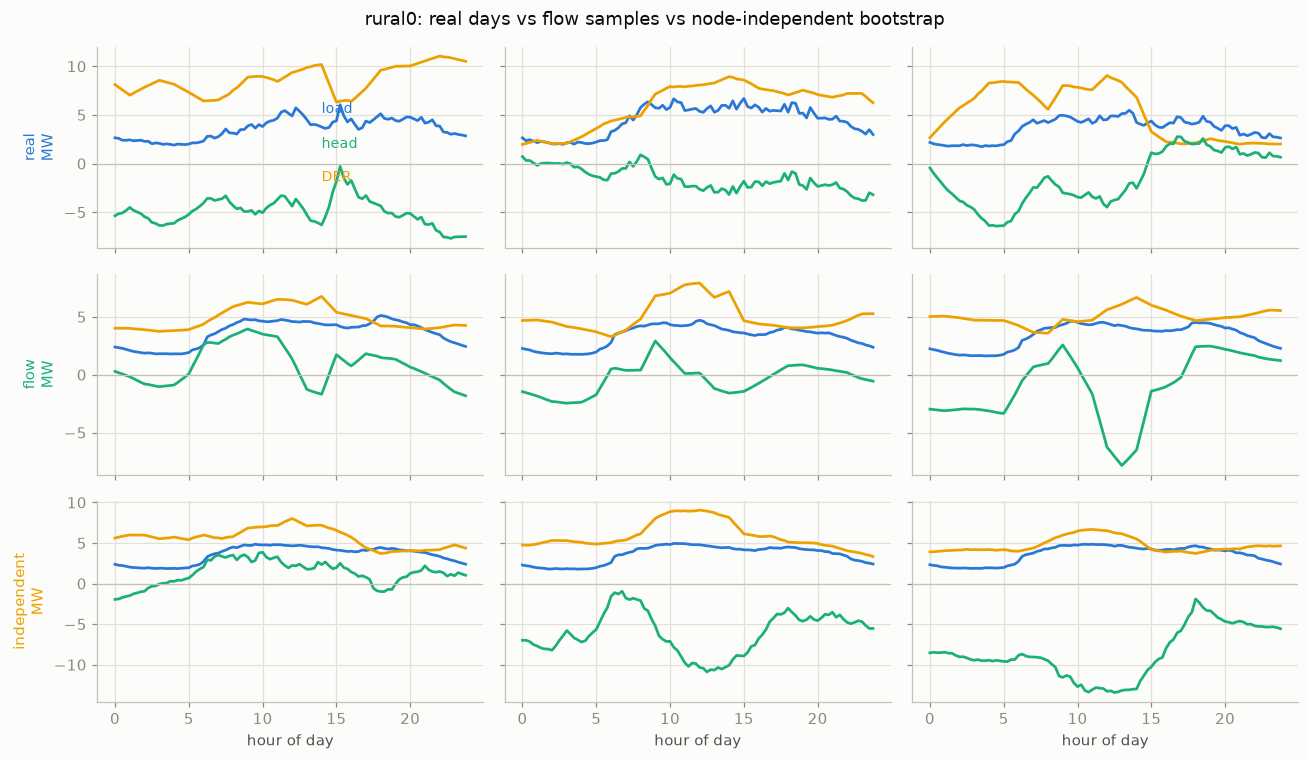

In [5]:
# fig07 — sample gallery, rural0 feeder-head + total load/DER
f = feeders["rural0"]; ref = f["ref_row"]
fig, axes = plt.subplots(3, 3, figsize=(12, 7), sharex=True, sharey="row")
hours = np.arange(96) / 4
for row, src in enumerate(["real", "flow", "independent"]):
    days = sets["rural0"][src]
    for col in range(3):
        ax = axes[row, col]
        d = days[col * 7 + 3]                          # arbitrary distinct picks
        ax.plot(hours, d[:, 0, :].sum(axis=0), lw=1.8, color=C["blue"])
        ax.plot(hours, d[:, 2, :].sum(axis=0) - d[ref, 2, :], lw=1.8, color=C["yellow"])
        ax.plot(hours, d[ref, 2, :], lw=1.8, color=C["aqua"])
        ax.axhline(0, color="#c3c2b7", lw=0.8)
        if col == 0:
            ax.set_ylabel(f"{src}\nMW", color=SRC.get(src, INK2))
for ax in axes[-1]:
    ax.set_xlabel("hour of day")
axes[0, 0].annotate("load", xy=(14, 5.2), color=C["blue"], fontsize=9)
axes[0, 0].annotate("DER", xy=(14, -1.8), color=C["yellow"], fontsize=9)
axes[0, 0].annotate("head", xy=(14, 1.6), color=C["aqua"], fontsize=9)
fig.suptitle("rural0: real days vs flow samples vs node-independent bootstrap",
             fontsize=12)
fig.tight_layout()
fig.savefig(RES / "fig07_gallery.png", bbox_inches="tight")
plt.show()

**Reading fig07** (written after looking). The real rows show the M1 regimes: wind-heavy
DER running all day, head deep in export. The flow rows are *plausible new days* — load
with the right diurnal shape, DER that varies between samples, heads that cross zero,
one deep −12 MW export excursion (the real feeder reaches −13.6 MW) — no sample copies
a training day. The independent rows expose that baseline's true nature: its "head" is a
real head series bootstrapped from an *unrelated* day, so it bears no relation to its own
load and DER (bottom-middle: moderate DER yet −10 MW export all day). **That means every
head-based statistical metric flatters the independent baseline** — it resamples real
data — while the sample is internally inconsistent. Per-channel statistics cannot see
this failure; only a *joint* consistency check can. That check is the physics residual,
and it arrives in M3 — this is the cleanest demonstration yet of why physics-informed generation
is a hard requirement here.

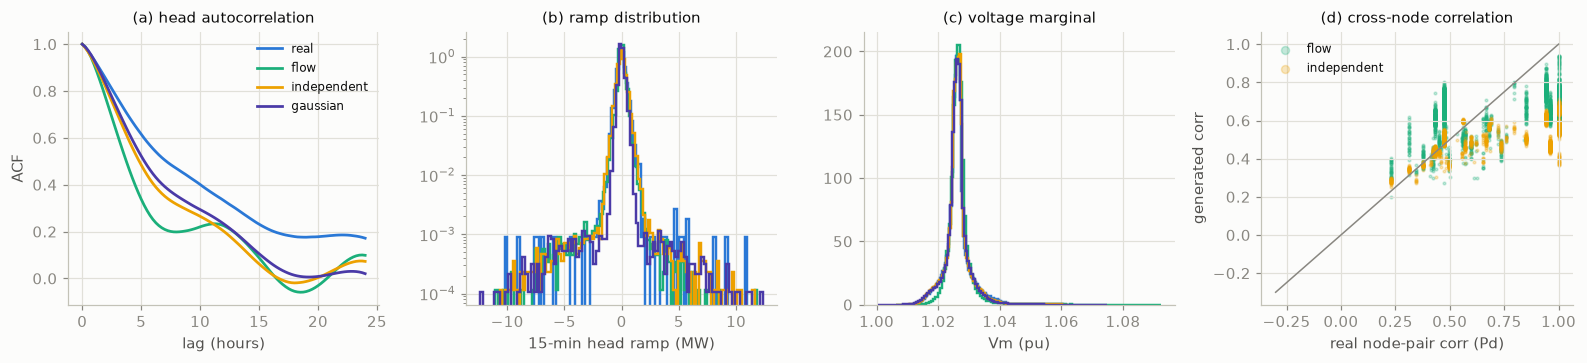

In [6]:
# fig08 — the four Cramer axes, real vs the three generators (rural0)
f = feeders["rural0"]; ref = f["ref_row"]
S = sets["rural0"]
fig, axes = plt.subplots(1, 4, figsize=(14.5, 3.4))

ax = axes[0]                                            # (a) head autocorrelation
for src in ["real", "flow", "independent", "gaussian"]:
    h = M.head_series(S[src], ref)
    ax.plot(np.arange(97) / 4, M.autocorr(h, 96), lw=1.8, color=SRC[src], label=src)
ax.set_xlabel("lag (hours)"); ax.set_ylabel("ACF")
ax.set_title("(a) head autocorrelation", fontsize=10)
ax.legend(frameon=False, fontsize=8)

ax = axes[1]                                            # (b) ramp tails
for src in ["real", "flow", "independent", "gaussian"]:
    ax.hist(np.diff(M.head_series(S[src], ref)), bins=100, density=True,
            histtype="step", lw=1.6, color=SRC[src])
ax.set_yscale("log"); ax.set_xlabel("15-min head ramp (MW)")
ax.set_title("(b) ramp distribution", fontsize=10)

ax = axes[2]                                            # (c) Vm marginal
for src in ["real", "flow", "independent", "gaussian"]:
    ax.hist(S[src][:, :, 4, :].ravel(), bins=120, density=True,
            histtype="step", lw=1.6, color=SRC[src])
ax.set_xlabel("Vm (pu)"); ax.set_title("(c) voltage marginal", fontsize=10)

ax = axes[3]                                            # (d) cross-node correlation
cr, keep = M.cross_node_corr(S["real"])
cf, _ = M.cross_node_corr(S["flow"], keep=keep)
iu = np.triu_indices_from(cr, k=1)
ax.scatter(cr[iu], cf[iu], s=3, alpha=0.25, color=C["aqua"], label="flow")
ci, _ = M.cross_node_corr(S["independent"], keep=keep)
ax.scatter(cr[iu], ci[iu], s=3, alpha=0.25, color=C["yellow"], label="independent")
ax.plot([-0.3, 1], [-0.3, 1], color=MUTED, lw=1)
ax.set_xlabel("real node-pair corr (Pd)"); ax.set_ylabel("generated corr")
ax.set_title("(d) cross-node correlation", fontsize=10)
ax.legend(frameon=False, fontsize=8, markerscale=3)
fig.tight_layout(); fig.savefig(RES / "fig08_fingerprints.png", bbox_inches="tight")
plt.show()

In [7]:
# the scorecard — every generator, both feeders, vs real validation days
rows = []
for n in TRAIN_FEEDERS:
    ref = feeders[n]["ref_row"]
    for src in ["flow", "independent", "gaussian", "pca_ceiling"]:
        sc = M.scorecard(sets[n]["real"], sets[n][src], ref, label=f"{n}/{src}")
        rows.append(sc)
score = pd.DataFrame(rows).set_index("label").round(4)
score.to_csv(RES / "m2_scorecard.csv")
score

,W1_Pd,W1_Qd,W1_Pg,W1_Qg,W1_Vm,W1_Va,ACF_head_rmse,PSD_head_l1,W1_head_ramps,XCorr_Pd_rmse,revflow_real_pct,revflow_gen_pct,revflow_abs_err_pct
label,,,,,,,,,,,,,
rural0/flow,0.0025,0.0009,0.0156,0.0017,0.0008,0.0105,0.1883,0.5141,0.0831,0.2397,56.5909,55.9974,0.5935
rural0/independent,0.0012,0.0003,0.0086,0.0001,0.0002,0.0008,0.1419,0.3612,0.0079,0.2717,56.5909,53.5573,3.0336
rural0/gaussian,0.0012,0.0004,0.0144,0.0002,0.0002,0.0017,0.1214,0.3487,0.1155,0.0304,56.5909,63.0938,6.5028
rural0/pca_ceiling,0.0003,0.0002,0.0003,0.0004,0.0000,0.0000,0.0034,0.0083,0.1222,0.0262,56.5909,56.9318,0.3409
semiurb0/flow,0.0038,0.0013,0.0153,0.0009,0.0005,0.0031,0.0687,0.3737,0.2266,0.2103,32.1591,38.6380,6.4789
semiurb0/independent,0.0025,0.0003,0.0064,0.0001,0.0002,0.0003,0.0408,0.2254,0.0172,0.3659,32.1591,34.7760,2.6170
semiurb0/gaussian,0.0026,0.0004,0.0092,0.0000,0.0002,0.0007,0.0526,0.2383,0.2852,0.0267,32.1591,35.0312,2.8722
semiurb0/pca_ceiling,0.0004,0.0004,0.0001,0.0001,0.0001,0.0001,0.0102,0.0321,0.2782,0.0169,32.1591,31.6098,0.5492


## Honest summary

**The flow does not dominate the scorecard — and the scorecard explains why that's the
wrong question.** Each baseline wins exactly the axis it was engineered for:
*independent* wins marginals, head-ACF and ramps because its channels ARE resampled real
data (see fig07 — internally inconsistent, but per-channel statistics can't tell);
*gaussian* wins cross-node correlation (0.03 vs the flow's 0.21–0.24 RMSE) because a
full-covariance fit in day-PCA space captures second moments by construction — at the
price of tails (worst ramp W1 on both feeders). The flow beats independent on
cross-node correlation and gaussian on ramps on both feeders, so the **plan-B trigger
recorded above is not tripped** — but v0's honest deficiencies are on the table:

1. **Head-ACF undershoot** (0.20/0.11 RMSE): sampled days lose temporal persistence at
   3–12 h lags — the weather envelope is too weak.
2. **Cross-node correlation compression**: node-pair correlations cluster near the
   diurnal-rhythm floor (~0.5) instead of spanning the real 0.2–1.0 range (fig08d).
   The global mean-context is evidently too thin a channel for feeder-wide weather.
3. **A physically implausible Vm tail to ~1.10 pu** (real max 1.062) — pure statistics
   permits voltages this feeder can never produce. Exhibit A for M3's physics loss.
4. **Overfitting from epoch ~155** (622 training days vs 1.6M params): early stopping
   handled it, but regularization (dequant noise, weight decay) and/or a smaller model
   are on M3's list, now with multi-seed error bars to judge them.

**What v0 delivers regardless:** end-to-end graph-conditioned sampling with exact
likelihood, one weight set across feeders, nameplate-normalized (transfer-safe), graded
on the validation axes of Cramer et al. against baselines that make the numbers meaningful —
and a measured, reproducible starting point for the M3 ablation. The K=16 basis
(fig05b) remains the ceiling for every generator in this representation; the σ=0.01
dequantization noise sets a small-amplitude floor on constant channels.

**The meta-lesson** (this is the bridge M2 → M3): statistical fidelity
metrics are *gameable* — a bootstrap wins them while violating the grid's joint physics.
The physics residual is the metric a generator cannot game, which is exactly why
physics-informed generation is the load-bearing requirement of trustworthy synthetic grid data.